In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for nicer plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

c:\Users\yezid\sec_sem_env\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde


✓ Libraries imported successfully!


In [2]:
# Cell 2: Load the CSV file
df = pd.read_csv('data/sample_logs/network_logs.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head(10)  # Show first 10 rows

Dataset shape: (10000, 13)

First few rows:


,timestamp,source_ip,dest_ip,source_port,dest_port,protocol,bytes_sent,bytes_received,packet_count,duration_seconds,flags,is_encrypted,label
0,2024-06-15T00:20:49,192.168.1.54,8.29.123.40,57964,80,TCP,2580.002040,823.219070,293,3.177071,FIN,True,normal
1,2024-06-28T18:31:24,192.168.1.16,8.108.102.159,53377,443,UDP,253.832276,2245.168122,499,4.677852,FIN,True,normal
2,2024-06-19T16:18:08,192.168.1.73,8.48.49.220,59375,3306,UDP,833.096459,2075.235239,268,2.938494,ACK,False,normal
3,2024-06-16T17:26:51,192.168.1.150,8.115.32.173,58887,61989,TCP,0.000000,0.000000,1,0.100000,SYN,False,port_scan
4,2024-06-07T09:06:21,192.168.1.24,8.232.1.134,59857,3306,UDP,1337.804470,3025.064492,262,21.436127,ACK,True,normal
5,2024-06-16T15:29:39,192.168.1.38,8.136.174.57,55027,443,UDP,3217.859840,425.029584,251,0.338664,ACK,True,normal
6,2024-06-02T10:27:06,192.168.1.148,8.54.79.139,61750,3306,TCP,2029.955173,1252.094189,181,5.943916,"SYN,ACK",True,normal
7,2024-06-30T18:58:22,192.168.1.131,8.48.49.220,57986,5432,UDP,5120.314641,3266.596897,144,2.250304,FIN,True,normal
8,2024-06-17T22:01:37,192.168.1.246,8.205.137.33,57254,443,TCP,1747.912800,2643.058624,185,2.891015,"SYN,ACK",True,normal
9,2024-06-12T09:36:36,192.168.1.121,8.64.65.243,50643,80,UDP,3197.913801,3841.290642,220,0.043282,"SYN,ACK,FIN",True,normal


In [3]:
# Cell 3: Data info
print("DATA TYPES:")
print(df.dtypes)
print("\n" + "="*60)

print("\nMISSING VALUES:")
print(df.isnull().sum())
print("\n" + "="*60)

print("\nSTATISTICAL SUMMARY:")
df.describe()

DATA TYPES:
timestamp            object
source_ip            object
dest_ip              object
source_port           int64
dest_port             int64
protocol             object
bytes_sent          float64
bytes_received      float64
packet_count          int64
duration_seconds    float64
flags                object
is_encrypted           bool
label                object
dtype: object


MISSING VALUES:
timestamp           0
source_ip           0
dest_ip             0
source_port         0
dest_port           0
protocol            0
bytes_sent          0
bytes_received      0
packet_count        0
duration_seconds    0
flags               0
is_encrypted        0
label               0
dtype: int64


STATISTICAL SUMMARY:


,source_port,dest_port,bytes_sent,bytes_received,packet_count,duration_seconds
count,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,57325.621500,1916.168200,1.820856e+04,1924.976481,264.086500,5.183296
std,4751.647281,5458.976174,1.326017e+05,1439.258319,175.412517,6.840802
min,49153.000000,22.000000,0.000000e+00,0.000000,1.000000,0.000084
25%,53218.750000,25.000000,9.373666e+02,881.063977,126.000000,1.263836
50%,57294.500000,80.000000,1.700676e+03,1618.800652,256.000000,3.305550
75%,61426.500000,3306.000000,2.789976e+03,2630.336471,382.000000,6.858440
max,65534.000000,65354.000000,2.318608e+06,14803.951628,1000.000000,143.024544


LABEL DISTRIBUTION:
label
normal               9500
port_scan             200
data_exfiltration     150
ddos                  150
Name: count, dtype: int64

PERCENTAGES:
label
normal               95.0
port_scan             2.0
data_exfiltration     1.5
ddos                  1.5
Name: proportion, dtype: float64


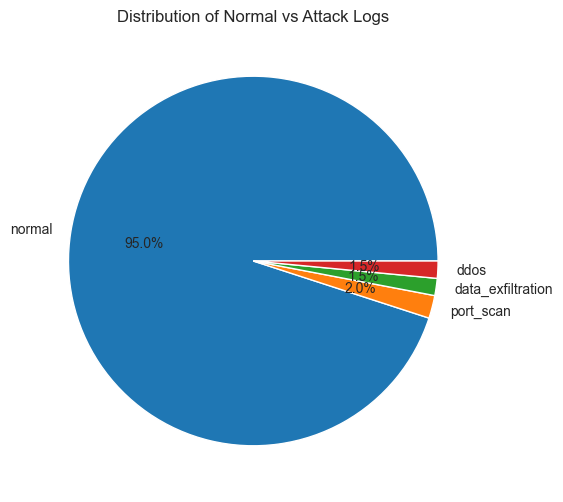

In [4]:
print("LABEL DISTRIBUTION:")
print(df['label'].value_counts())
print("\nPERCENTAGES:")
print(df['label'].value_counts(normalize=True) * 100)

# Visualize as pie chart
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 6))
plt.title('Distribution of Normal vs Attack Logs')
plt.ylabel('')
plt.show()

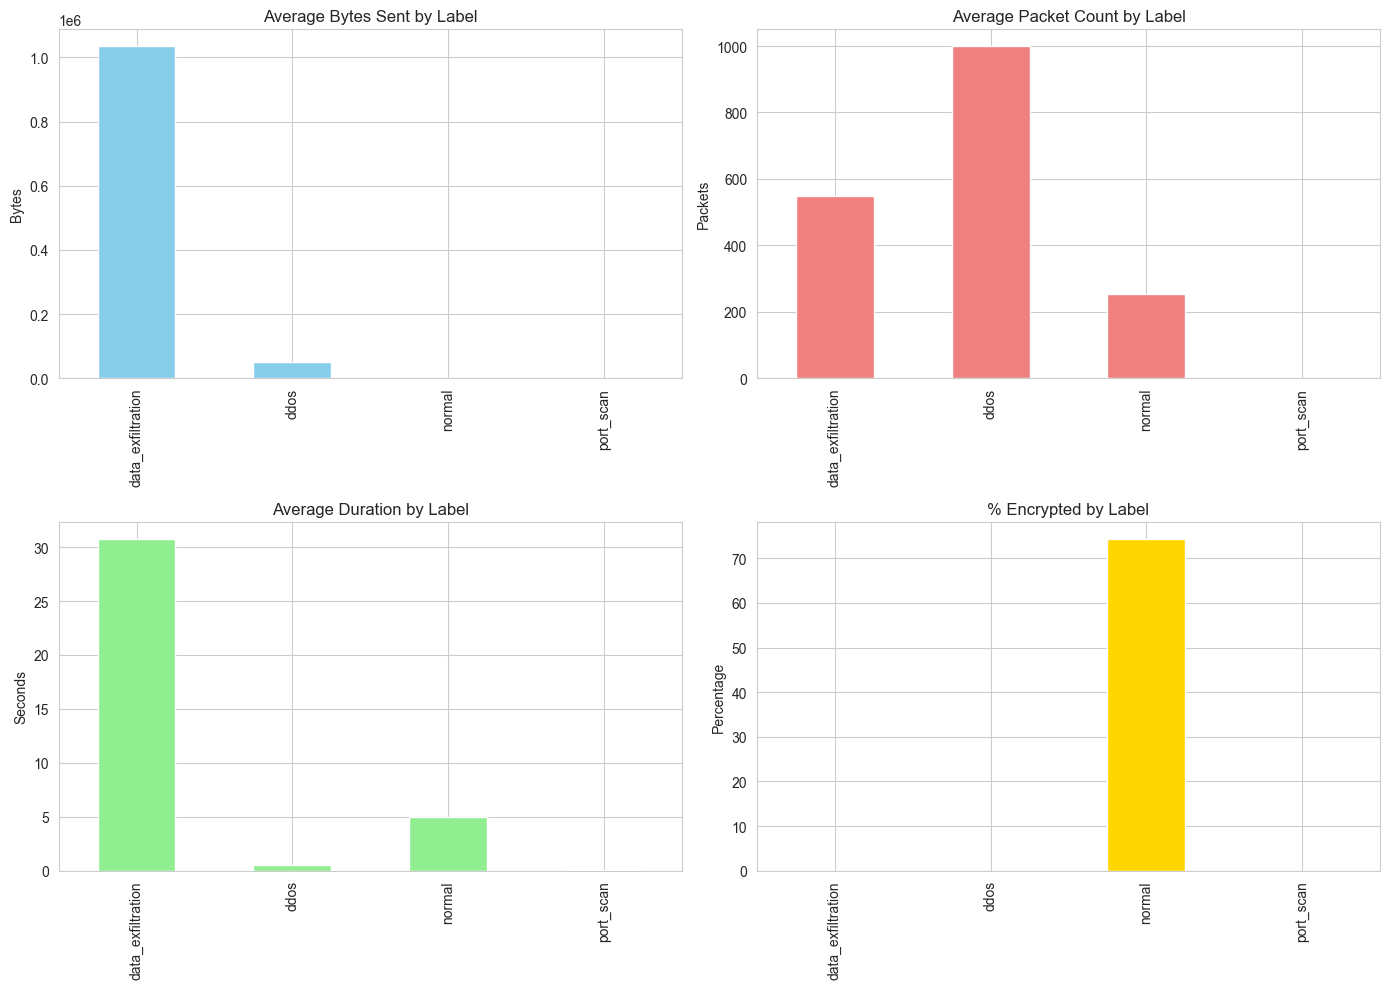

In [5]:
# Cell 6: Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Bytes sent distribution
df.groupby('label')['bytes_sent'].mean().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Average Bytes Sent by Label')
axes[0, 0].set_ylabel('Bytes')
axes[0, 0].set_xlabel('')

# Plot 2: Packet count distribution
df.groupby('label')['packet_count'].mean().plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Average Packet Count by Label')
axes[0, 1].set_ylabel('Packets')
axes[0, 1].set_xlabel('')

# Plot 3: Duration distribution
df.groupby('label')['duration_seconds'].mean().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Average Duration by Label')
axes[1, 0].set_ylabel('Seconds')
axes[1, 0].set_xlabel('')

# Plot 4: Encryption distribution
encryption_by_label = df.groupby('label')['is_encrypted'].apply(lambda x: (x.sum() / len(x) * 100))
encryption_by_label.plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('% Encrypted by Label')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()

In [6]:
# Cell 7: Show specific examples of each attack type
print("SAMPLE LOGS FROM EACH ATTACK TYPE:\n")

for label in ['normal', 'port_scan', 'ddos', 'data_exfiltration']:
    print(f"\n{'='*80}")
    print(f"{label.upper()} - EXAMPLE")
    print(f"{'='*80}")
    
    sample = df[df['label'] == label].iloc[0]
    
    print(f"\nTimestamp:        {sample['timestamp']}")
    print(f"Source IP:        {sample['source_ip']}")
    print(f"Dest IP:          {sample['dest_ip']}")
    print(f"Source Port:      {sample['source_port']}")
    print(f"Dest Port:        {sample['dest_port']}")
    print(f"Protocol:         {sample['protocol']}")
    print(f"Bytes Sent:       {sample['bytes_sent']:,.0f}")
    print(f"Bytes Received:   {sample['bytes_received']:,.0f}")
    print(f"Packet Count:     {sample['packet_count']}")
    print(f"Duration:         {sample['duration_seconds']:.2f} seconds")
    print(f"Flags:            {sample['flags']}")
    print(f"Encrypted:        {sample['is_encrypted']}")

SAMPLE LOGS FROM EACH ATTACK TYPE:


NORMAL - EXAMPLE

Timestamp:        2024-06-15T00:20:49
Source IP:        192.168.1.54
Dest IP:          8.29.123.40
Source Port:      57964
Dest Port:        80
Protocol:         TCP
Bytes Sent:       2,580
Bytes Received:   823
Packet Count:     293
Duration:         3.18 seconds
Flags:            FIN
Encrypted:        True

PORT_SCAN - EXAMPLE

Timestamp:        2024-06-16T17:26:51
Source IP:        192.168.1.150
Dest IP:          8.115.32.173
Source Port:      58887
Dest Port:        61989
Protocol:         TCP
Bytes Sent:       0
Bytes Received:   0
Packet Count:     1
Duration:         0.10 seconds
Flags:            SYN
Encrypted:        False

DDOS - EXAMPLE

Timestamp:        2024-06-06T21:37:06
Source IP:        192.168.1.148
Dest IP:          8.181.216.210
Source Port:      64974
Dest Port:        80
Protocol:         TCP
Bytes Sent:       34,019
Bytes Received:   0
Packet Count:     1000
Duration:         0.50 seconds
Flags:            SY